In [ ]:
using PyPlot
using JLD2
using Statistics

In [ ]:
pathdir_old_ds = "//DyLabNAS/Data/TwoDGas/2025/07/04"
pathdir_new_ds = "Y:/TwoDGas/2026/01/19/0047"

r = 100
N_atoms = 1.3e5
γ = 32.7e6 # In Hz
λ = 421e-9

x_crop = [1100:1700;]
y_crop = [1750:2450;]

sat_exp_old = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
sat_exp_new = [0.004, 0.4, 1.7, 4.7, 10, 16.5, 23, 28.5, 33, 37.5]; # Estimated saturation parameter

### Load data

In [ ]:
@load "Sol_full_imgs_integrated_"*join(split(pathdir_old_ds, "/")[6:end], "_")*".jld2" Iatoms_per_sat Ibkg_per_sat Idark_per_sat
Iatoms_per_sat_old_ds, Ibkg_per_sat_old_ds, Idark_per_sat_old_ds = Iatoms_per_sat, Ibkg_per_sat, Idark_per_sat

@load "Sol_full_imgs_integrated_"*join(split(pathdir_new_ds, "/")[3:end], "_")*".jld2" Iatoms_per_sat Ibkg_per_sat Idark_per_sat
Iatoms_per_sat_new_ds, Ibkg_per_sat_new_ds, Idark_per_sat_new_ds = Iatoms_per_sat, Ibkg_per_sat, Idark_per_sat;

### Load sim

In [ ]:
@load "Solutions_sim/Itot_N_30_r_100_sat_[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]_n0_1279_decay_rate_up_up.jdl2" Itot nbr_error_t_N sat;

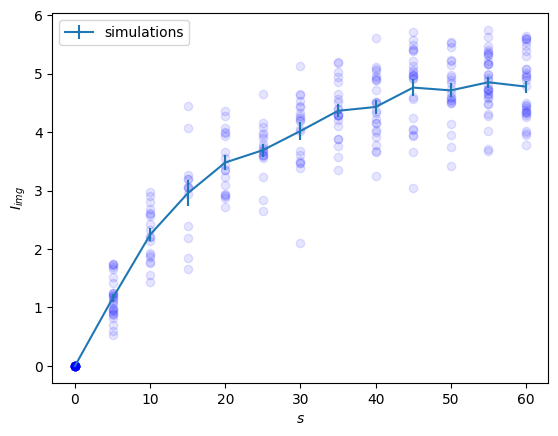

In [ ]:
close("all")
fig = subplots()

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label="simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

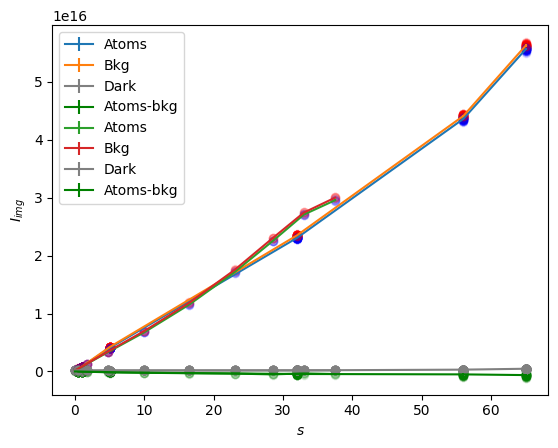

In [ ]:
close("all")
fig = subplots()

# Old dataset
errorbar(sat_exp_old, vec(mean(Iatoms_per_sat_old_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_old_ds, dims = 2)), label="Atoms")
errorbar(sat_exp_old, vec(mean(Ibkg_per_sat_old_ds, dims = 2)), yerr=vec(std(Ibkg_per_sat_old_ds, dims = 2)), label="Bkg")
errorbar(sat_exp_old, vec(mean(Idark_per_sat_old_ds, dims = 2)), yerr=vec(std(Idark_per_sat_old_ds, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp_old, vec(mean(Iatoms_per_sat_old_ds, dims = 2))-vec(mean(Ibkg_per_sat_old_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2)), label="Atoms-bkg", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], Iatoms_per_sat_old_ds[i, j], color="b", alpha = 0.1)
        scatter(sat_exp_old[i], Ibkg_per_sat_old_ds[i, j], color="r", alpha = 0.1)
        scatter(sat_exp_old[i], Iatoms_per_sat_old_ds[i, j]-Ibkg_per_sat_old_ds[i, j], color="g", alpha = 0.1)
        scatter(sat_exp_old[i], Idark_per_sat_old_ds[i, j], color="grey")
    end
end

# New dataset
errorbar(sat_exp_new, vec(mean(Iatoms_per_sat_new_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_new_ds, dims = 2)), label="Atoms")
errorbar(sat_exp_new, vec(mean(Ibkg_per_sat_new_ds, dims = 2)), yerr=vec(std(Ibkg_per_sat_new_ds, dims = 2)), label="Bkg")
errorbar(sat_exp_new, vec(mean(Idark_per_sat_new_ds, dims = 2)), yerr=vec(std(Idark_per_sat_new_ds, dims = 2)), label="Dark", color="grey")
errorbar(sat_exp_new, vec(mean(Iatoms_per_sat_new_ds, dims = 2))-vec(mean(Ibkg_per_sat_new_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2)), label="Atoms-bkg", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], Iatoms_per_sat_new_ds[i, j], color="b", alpha = 0.1)
        scatter(sat_exp_new[i], Ibkg_per_sat_new_ds[i, j], color="r", alpha = 0.1)
        scatter(sat_exp_new[i], Iatoms_per_sat_new_ds[i, j]-Ibkg_per_sat_new_ds[i, j], color="g", alpha = 0.1)
        scatter(sat_exp_new[i], Idark_per_sat_new_ds[i, j], color="grey")
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# pygui(true); show();
pygui(false);

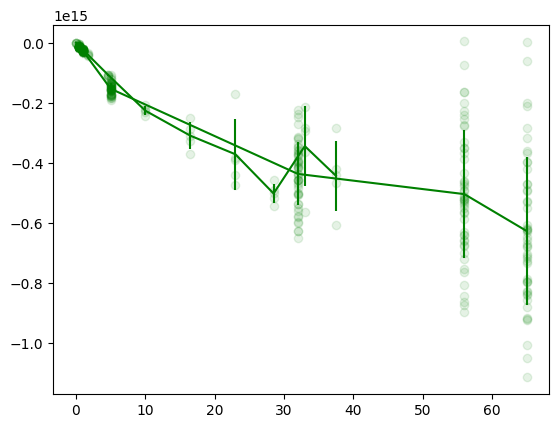

In [ ]:
close("all")
fig = subplots()

# Old dataset
errorbar(sat_exp_old, vec(mean(Iatoms_per_sat_old_ds, dims = 2))-vec(mean(Ibkg_per_sat_old_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2)), label="Atoms-bkg", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], Iatoms_per_sat_old_ds[i, j]-Ibkg_per_sat_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(sat_exp_new, vec(mean(Iatoms_per_sat_new_ds, dims = 2))-vec(mean(Ibkg_per_sat_new_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2)), label="Atoms-bkg", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], Iatoms_per_sat_new_ds[i, j]-Ibkg_per_sat_new_ds[i, j], color="g", alpha = 0.1)
    end
end

# pygui(true); show();
pygui(false);

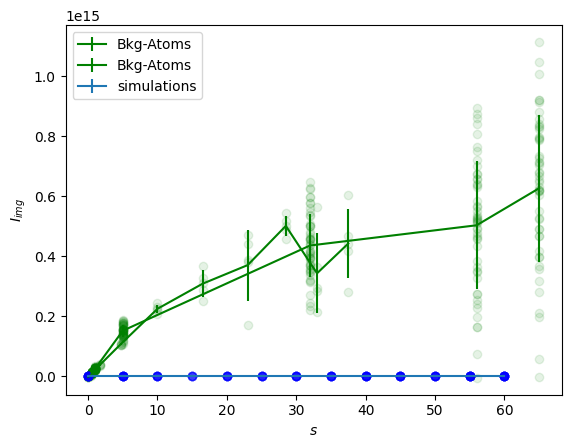

PyObject <matplotlib.legend.Legend object at 0x0000017C965C8A50>

In [ ]:
close("all")
fig = subplots()

# Old dataset
errorbar(sat_exp_old, vec(mean(Ibkg_per_sat_old_ds, dims = 2))-vec(mean(Iatoms_per_sat_old_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2)), label="Bkg-Atoms", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], Ibkg_per_sat_old_ds[i, j]-Iatoms_per_sat_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(sat_exp_new, vec(mean(Ibkg_per_sat_new_ds, dims = 2))-vec(mean(Iatoms_per_sat_new_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2)), label="Bkg-Atoms", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], Ibkg_per_sat_new_ds[i, j]-Iatoms_per_sat_new_ds[i, j], color="g", alpha = 0.1)
    end
end

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label="simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

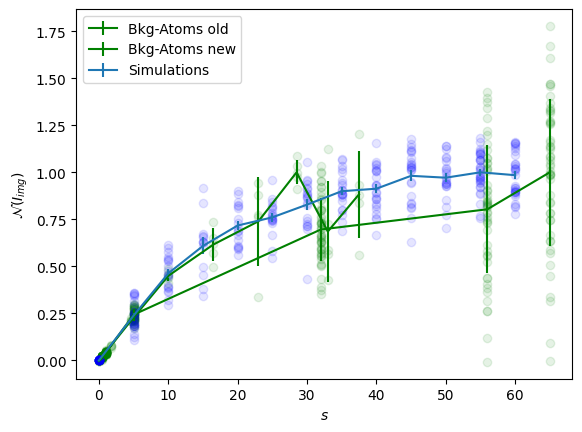

PyObject <matplotlib.legend.Legend object at 0x0000017C98190B90>

In [ ]:
close("all")
fig = subplots()

# Old dataset
max_old = maximum(vec(mean(Ibkg_per_sat_old_ds, dims = 2))-vec(mean(Iatoms_per_sat_old_ds, dims = 2)))
errorbar(sat_exp_old, (vec(mean(Ibkg_per_sat_old_ds, dims = 2))-vec(mean(Iatoms_per_sat_old_ds, dims = 2)))/max_old, yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2))/max_old, label="Bkg-Atoms old", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], (Ibkg_per_sat_old_ds[i, j]-Iatoms_per_sat_old_ds[i, j])/max_old, color="g", alpha = 0.1)
    end
end

# New dataset
max_new = maximum(vec(mean(Ibkg_per_sat_new_ds, dims = 2))-vec(mean(Iatoms_per_sat_new_ds, dims = 2)))
errorbar(sat_exp_new, (vec(mean(Ibkg_per_sat_new_ds, dims = 2))-vec(mean(Iatoms_per_sat_new_ds, dims = 2)))/max_new, yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2))/max_new, label="Bkg-Atoms new", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], (Ibkg_per_sat_new_ds[i, j]-Iatoms_per_sat_new_ds[i, j])/max_new, color="g", alpha = 0.1)
    end
end

max_sim = maximum([mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)])
errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]/max_sim, yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)]/max_sim, label="Simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j]/max_sim, alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"\mathcal{N}(I_{img})")

legend()

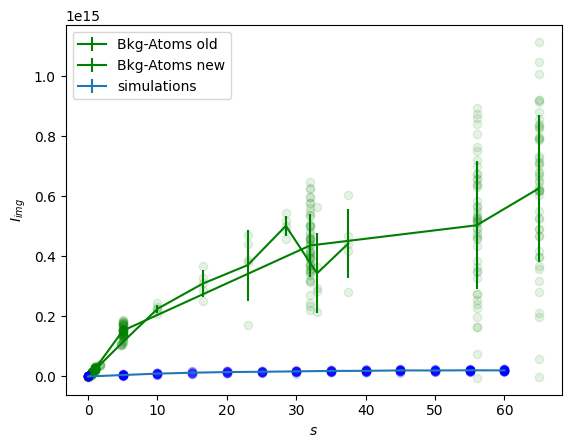

PyObject <matplotlib.legend.Legend object at 0x0000017CF1B56C10>

In [ ]:
close("all")
fig = subplots()

# Old dataset
errorbar(sat_exp_old, vec(mean(Ibkg_per_sat_old_ds, dims = 2))-vec(mean(Iatoms_per_sat_old_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2)), label="Bkg-Atoms old", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], Ibkg_per_sat_old_ds[i, j]-Iatoms_per_sat_old_ds[i, j], color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(sat_exp_new, vec(mean(Ibkg_per_sat_new_ds, dims = 2))-vec(mean(Iatoms_per_sat_new_ds, dims = 2)), yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2)), label="Bkg-Atoms new", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], Ibkg_per_sat_new_ds[i, j]-Iatoms_per_sat_new_ds[i, j], color="g", alpha = 0.1)
    end
end

facteur_sim = N_atoms*γ

errorbar(sat, facteur_sim*[mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)], yerr=facteur_sim*[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)], label="simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], facteur_sim*Itot[i, j], alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

# Putting the correct factor

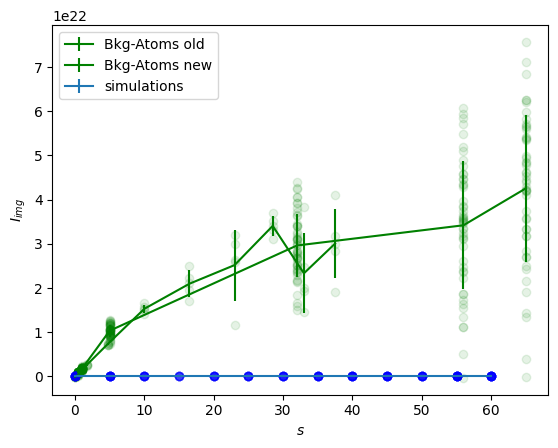

PyObject <matplotlib.legend.Legend object at 0x0000017C93DFD950>

In [ ]:
close("all")
fig = subplots()

pxl2msquared = length(x_crop)*length(y_crop)*(0.187e-6)^2
sim2msquared = 6*(0.2862531251442185 * λ)^2

# Old dataset
errorbar(sat_exp_old, (vec(mean(Ibkg_per_sat_old_ds, dims = 2))-vec(mean(Iatoms_per_sat_old_ds, dims = 2)))/pxl2msquared, yerr=vec(std(Iatoms_per_sat_old_ds-Ibkg_per_sat_old_ds, dims = 2))/pxl2msquared, label="Bkg-Atoms old", color="green")

for i = 1:length(sat_exp_old)
    for j = 1:length(Iatoms_per_sat_old_ds[i,:])
        scatter(sat_exp_old[i], (Ibkg_per_sat_old_ds[i, j]-Iatoms_per_sat_old_ds[i, j])/pxl2msquared, color="g", alpha = 0.1)
    end
end

# New dataset
errorbar(sat_exp_new, (vec(mean(Ibkg_per_sat_new_ds, dims = 2))-vec(mean(Iatoms_per_sat_new_ds, dims = 2)))/pxl2msquared, yerr=vec(std(Iatoms_per_sat_new_ds-Ibkg_per_sat_new_ds, dims = 2))/pxl2msquared, label="Bkg-Atoms new", color="green")

for i = 1:length(sat_exp_new)
    for j = 1:length(Iatoms_per_sat_new_ds[i,:])
        scatter(sat_exp_new[i], (Ibkg_per_sat_new_ds[i, j]-Iatoms_per_sat_new_ds[i, j])/pxl2msquared, color="g", alpha = 0.1)
    end
end

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]/sim2msquared, yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)]/sim2msquared, label="simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j]/sim2msquared, alpha=0.1, color="blue")
        end
    end
end

xlabel(L"s")
ylabel(L"I_{img}")

legend()

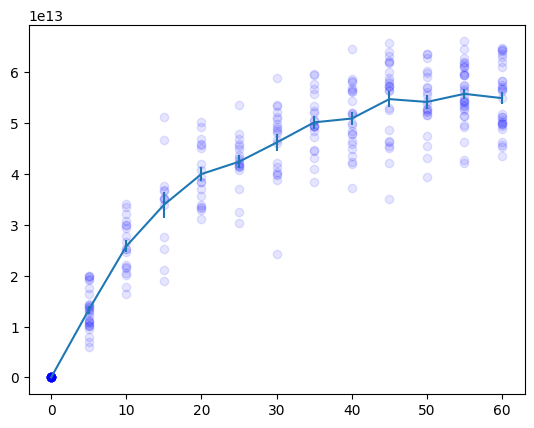

In [ ]:

errorbar(sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]/sim2msquared, yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(sat)]/sim2msquared, label="simulations")

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j]/sim2msquared, alpha=0.1, color="blue")
        end
    end
end